**Open h5 results file**

This code opens the h5 file and prints its structure, to make easier to find objects

In [ ]:
# Open h5 file and import necessary modules
import h5py

def inspect_h5_file(file_path):
    def print_structure(name, obj):
        # Evaluate needed identation based on the depth in the hierarchy
        indent = '  ' * name.count('/')

        if isinstance(obj, h5py.Group):
            print(f"{indent}Group: {name}")
        elif isinstance(obj, h5py.Group):
            print(f"{indent}Dataset: {name} - Shape: {obj.shape}, Dtype: {obj.dtype}")

            if obj.attrs:
                for attr_name, attr_value in obj.attrs.items():
                    print(f"{indent}  Attribute: {attr_name} = {attr_value}")

    print(f"Inspecting HDF5 file: {file_path}")
    with h5py.File(file_path, 'r') as h5file:
        h5file.visititems(print_structure)

# Example usage
file_path = r'output\20260209110723-1\optimization_results.h5'
inspect_h5_file(file_path)

Inspecting HDF5 file: output\20260205175237-1\optimization_results.h5
Group: design
  Group: design/networks
    Group: design/networks/2022
      Group: design/networks/2022/hydrogenPipelineOnshore
        Group: design/networks/2022/hydrogenPipelineOnshore/BEL1BEL2
        Group: design/networks/2022/hydrogenPipelineOnshore/BEL1DE
        Group: design/networks/2022/hydrogenPipelineOnshore/BEL1NL1
        Group: design/networks/2022/hydrogenPipelineOnshore/BEL1NL2
        Group: design/networks/2022/hydrogenPipelineOnshore/BEL1NL3
        Group: design/networks/2022/hydrogenPipelineOnshore/BEL2BEL1
        Group: design/networks/2022/hydrogenPipelineOnshore/BEL2DE
        Group: design/networks/2022/hydrogenPipelineOnshore/BEL2NL1
        Group: design/networks/2022/hydrogenPipelineOnshore/BEL2NL2
        Group: design/networks/2022/hydrogenPipelineOnshore/BEL2NL3
        Group: design/networks/2022/hydrogenPipelineOnshore/DEBEL1
        Group: design/networks/2022/hydrogenPipelineOn

In [12]:
from __future__ import annotations
import h5py
import numpy as np
import pandas as pd
from pathlib import Path

def _to_scalar(x):
    """
    Convert dataset HDF5 to Python scalar if possible.
    Handles: scalars, 0-d arrays, 1-element arrays.
    """
    if isinstance(x, (np.generic,)):
        return float(x.item())
    x = np.asarray(x)
    if x.shape == ():          # 0-d
        return float(x.item())
    if x.size == 1:
        return float(x.reshape(-1)[0].item())
    return x  # if it's a real array (should not be for capex_tot)

def create_base_df(h5_path: str | Path,
                   year: str = "2022") -> pd.DataFrame:
    """
    Check structure of the HDF5 file and create a base DataFrame for design results.
    DF structure:
    | node | component |
    """
    h5_path = Path(h5_path)

    rows = []
    base = f"design/nodes/{year}"
    
    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in the file.")

        g_year = f[base]

        for node in g_year.keys():
            g_node_path = f"{base}/{node}"
            g_node = f[g_node_path]

            for comp in g_node.keys():
                rows.append({"node": node, "component": comp})
        
    df = pd.DataFrame(rows)

    return df
        

def load_design_results(dataset_name: str,
                      h5_path: str | Path,
                      year: str = "2022",
                      base_df: pd.DataFrame | None = None) -> pd.DataFrame:
    """
    Extracts dataset_name for each component: design/nodes/{year}/{node}/{component}/{dataset_name}
    Adds dataset_name to the base DataFrame created by create_base_df.
    DF structure:
    | node | component | dataset_name |
    """
    h5_path = Path(h5_path)
    base = f"design/nodes/{year}"

    if base_df is None:
        df = create_base_df(h5_path, year)
    else:
        df = base_df.copy()
        if not isinstance(df.index, pd.MultiIndex) or df.index.names != ['node', 'component']:
            df = df.set_index(['node', 'component']).sort_index()

    # Add dataset_name to the base DataFrame created by create_base_df
    df[dataset_name] = np.nan  # initialize column dataset_name with NaN

    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in the file.")
        
        g_year = f[base]

        for node in g_year.keys():
            g_node_path = f"{base}/{node}"
            g_node = f[g_node_path]

            for comp in g_node.keys():
                ds_path = f"{g_node_path}/{comp}/{dataset_name}"
                if ds_path in f:
                    val = _to_scalar(f[ds_path][()])
                    # # Check if the node/component pair exists in the base DataFrame
                    # mask = (df['node'] == node) & (df['component'] == comp)
                    # if mask.any():
                    #     df.loc[mask, dataset_name] = val
                    # else:
                    #     print(f"Warning: node/component pair ({node}, {comp}) not found in base DataFrame. Skipping {dataset_name} for this pair.")
                    df.loc[(node, comp), dataset_name] = val

    return df.reset_index()

results_path = r"output\20260209110723-1\optimization_results.h5"
year = '2022'

# Create standard df for design results
components_df = create_base_df(results_path, year)

# Load capex data
components_df = load_design_results("capex_tot", results_path, year, components_df)

# Load size data
components_df = load_design_results("size", results_path, year, components_df)

print(components_df)

     node        component     capex_tot        size
0    BEL1              ASU  0.000000e+00    0.000000
1    BEL1        Boiler_El  8.627640e+05   59.919149
2    BEL1   CrackerFurnace  1.775715e+08  723.414121
3    BEL1     Electrolyzer  0.000000e+00    0.000000
4    BEL1     HBfeed_mixer  0.000000e+00    0.000000
..    ...              ...           ...         ...
103   NL3       WGS_syngas  0.000000e+00    0.000000
104   NL3  eCrackerFurnace  0.000000e+00    0.000000
105   NL3      eSMR_syngas  0.000000e+00    0.000000
106   NL3    feedgas_mixer  0.000000e+00    0.000000
107   NL3             rWGS  0.000000e+00    0.000000

[108 rows x 4 columns]


**Pipeline design map**

This code opens the h5 file and plots the map according to the positions of the nodes and the installed pipeline. Thickness of the lines is based on **design** variable

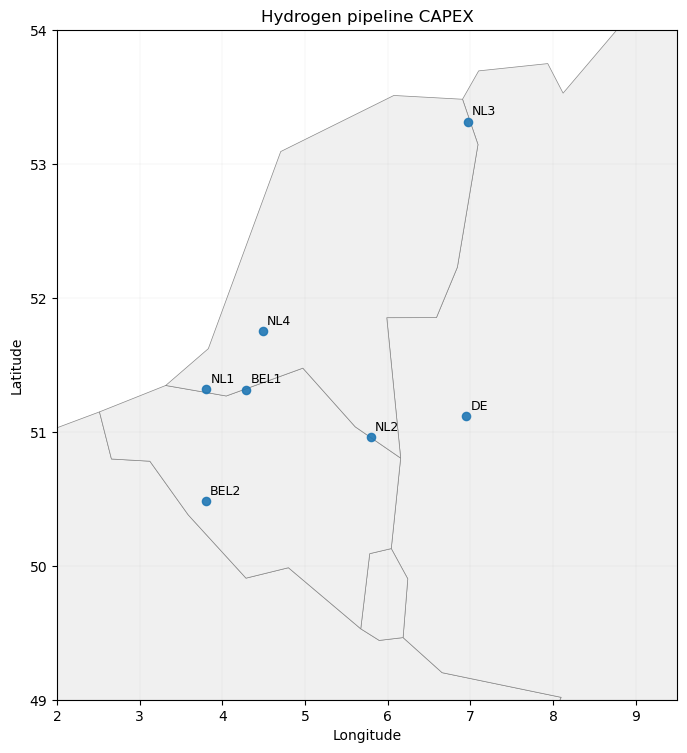

In [5]:
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import h5py
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString, Point

def _to_scalar(x):
    """Convert HDF5 dataset to Python scalar if possible, with special handling for bytes -> str."""
    if isinstance(x, (bytes, bytearray)):
        return x.decode("utf-8")
    if isinstance(x, np.generic):
        v = x.item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    x = np.asarray(x)
    if x.shape == ():
        v = x.item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    if x.size == 1:
        v = x.reshape(-1)[0].item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    # array vero
    if x.dtype.kind in ("S", "O"):
        try:
            return np.vectorize(lambda b: b.decode("utf-8") if isinstance(b, (bytes, bytearray)) else b)(x)
        except Exception:
            pass
    return x

def read_network_edges(h5_path: str | Path,
                       year: str = "2022",
                       network: str = "hydrogenPipelineOnshore",
                       dataset: str = "capex") -> pd.DataFrame:
    """
    design/networks/{year}/{network}/{edge_id}/...
    Reads the selected dataset along with fromNode and toNode if they exist.
    """
    h5_path = Path(h5_path)
    base = f"design/networks/{year}/{network}"

    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in the file.")
        g = f[base]
        edge_ids = list(g.keys())

        rows = []
        for eid in edge_ids:
            row = {"edge_id": eid}

            p_val = f"{base}/{eid}/{dataset}"
            p_from = f"{base}/{eid}/fromNode"
            p_to = f"{base}/{eid}/toNode"

            row[dataset] = _to_scalar(f[p_val][()]) if p_val in f else np.nan
            row["fromNode"] = _to_scalar(f[p_from][()]) if p_from in f else np.nan
            row["toNode"] = _to_scalar(f[p_to][()]) if p_to in f else np.nan
            rows.append(row)

    return pd.DataFrame(rows)

def attach_geometry(edges_df: pd.DataFrame, nodes_csv: str | Path) -> pd.DataFrame:
    """
    Adds lon/lat columns for from/to using plants_clusters_summary.csv
    (expected columns: cluster, latitude, longitude)
    """
    nodes = pd.read_csv(nodes_csv)
    nodes["cluster"] = nodes["cluster"].astype(str)

    coords = nodes.set_index("cluster")[["latitude", "longitude"]]

    out = edges_df.copy()
    out["fromNode"] = out["fromNode"].astype(str)
    out["toNode"]   = out["toNode"].astype(str)

    out["from_lat"] = out["fromNode"].map(coords["latitude"])
    out["from_lon"] = out["fromNode"].map(coords["longitude"])
    out["to_lat"]   = out["toNode"].map(coords["latitude"])
    out["to_lon"]   = out["toNode"].map(coords["longitude"])
    return out

def make_geopandas_map(edges_df: pd.DataFrame,
                       nodes_csv: str | Path,
                       weight_col: str = "capex",
                       bbox=(2.0, 49.0, 9.5, 54.0),
                       min_width=0.5,
                       max_width=6.0,
                       title=None):
    """
    Plots with GeoPandas + Matplotlib:
    - NaturalEarth basemap
    - nodes as points
    - edges as LineString with linewidth scaled on weight_col
    """
    nodes = pd.read_csv(nodes_csv)
    nodes["cluster"] = nodes["cluster"].astype(str)

    # GeoDataFrame nodes
    g_nodes = gpd.GeoDataFrame(
        nodes,
        geometry=gpd.points_from_xy(nodes["longitude"], nodes["latitude"]),
        crs="EPSG:4326"
    )

    # Filter valid edges and create LineString
    ed = edges_df.copy()
    ed[weight_col] = pd.to_numeric(ed[weight_col], errors="coerce")

    valid = ed[["from_lon","from_lat","to_lon","to_lat"]].notna().all(axis=1)
    ed = ed.loc[valid].copy()

    ed["geometry"] = ed.apply(
        lambda r: LineString([(r["from_lon"], r["from_lat"]), (r["to_lon"], r["to_lat"])]),
        axis=1
    )
    g_edges = gpd.GeoDataFrame(ed, geometry="geometry", crs="EPSG:4326")

    # Clip on bbox (lon_min, lat_min, lon_max, lat_max)
    lon_min, lat_min, lon_max, lat_max = bbox
    g_nodes_roi = g_nodes.cx[lon_min:lon_max, lat_min:lat_max]
    g_edges_roi = g_edges.cx[lon_min:lon_max, lat_min:lat_max]

    # Basemap
    world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")
    world_roi = world.cx[lon_min:lon_max, lat_min:lat_max]

    # Scale linewidth
    w = g_edges_roi[weight_col].to_numpy(dtype=float)
    w_pos = w[np.isfinite(w) & (w > 0)]
    w_max = float(w_pos.max()) if w_pos.size else 0.0

    def _lw(val):
        if not np.isfinite(val) or val <= 0 or w_max <= 0:
            return 0.0
        return min_width + (max_width - min_width) * (val / w_max)

    g_edges_roi["lw"] = g_edges_roi[weight_col].apply(_lw)

    # Plot
    fig, ax = plt.subplots(figsize=(8, 9))
    world_roi.plot(ax=ax, color="#f0f0f0", edgecolor="#888888", linewidth=0.5)

    # plot edges: draw only those with lw>0 (so zeros don't "pollute")
    g_edges_plot = g_edges_roi[g_edges_roi["lw"] > 0]
    if len(g_edges_plot):
        for lw_i in sorted(g_edges_plot["lw"].unique()):
            g_edges_plot[g_edges_plot["lw"] == lw_i].plot(ax=ax, linewidth=lw_i, alpha=0.8)

    # nodes
    g_nodes_roi.plot(ax=ax, markersize=35, alpha=0.9)

    # node labels (optional: comment out if cluttered)
    for _, r in g_nodes_roi.iterrows():
        ax.text(r["longitude"] + 0.05, r["latitude"] + 0.05, str(r["cluster"]), fontsize=9)

    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(title or f"Network {weight_col} (scaled linewidth)")
    ax.grid(True, linewidth=0.2, alpha=0.4)

    return fig, ax, g_nodes_roi, g_edges_roi


# main
h5_path = r"output\backbone_20260213171631-1\optimization_results.h5"
nodes_csv = r"case_studies\backbone\plants_clusters_summary.csv"
year = "2022"

edges = read_network_edges(h5_path, year=year, network="hydrogenPipelineOnshore", dataset="capex")
edges = attach_geometry(edges, nodes_csv)

fig, ax, g_nodes_roi, g_edges_roi = make_geopandas_map(
    edges, nodes_csv, weight_col="capex",
    title="Hydrogen pipeline CAPEX"
)
plt.show()


**Stacked columns plot according to design variables**

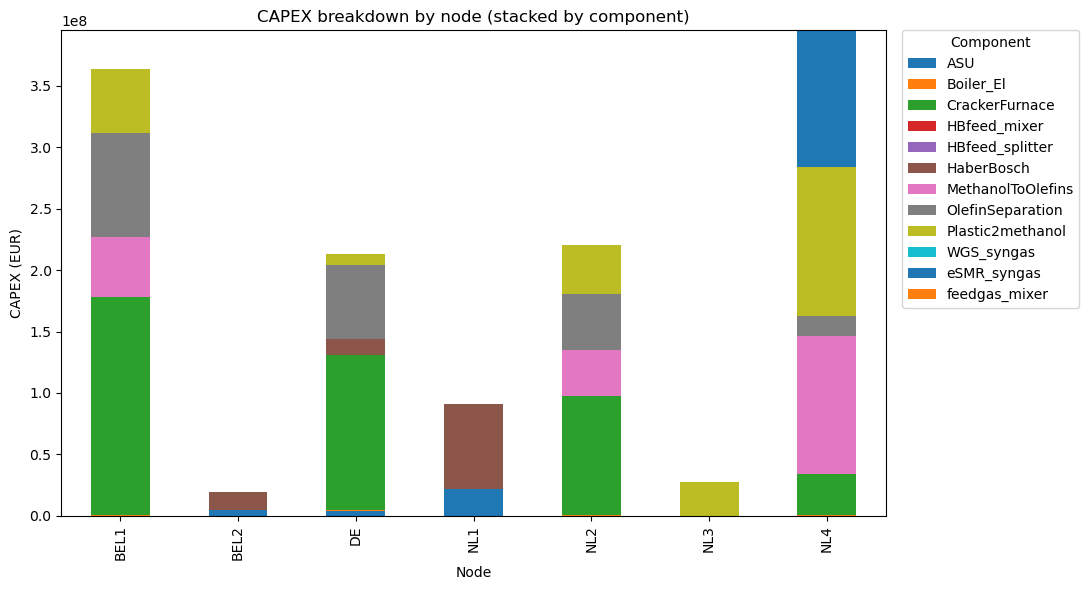

In [3]:
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt

def _to_scalar(x):
    """HDF5 dataset -> python scalar, decodifica bytes."""
    if isinstance(x, (bytes, bytearray)):
        return x.decode("utf-8")
    if isinstance(x, np.generic):
        v = x.item()
        if isinstance(v, (bytes, bytearray)):
            return v.decode("utf-8")
        return v
    x = np.asarray(x)
    if x.shape == ():
        v = x.item()
        if isinstance(v, (bytes, bytearray)):
            return v.decode("utf-8")
        return v
    if x.size == 1:
        v = x.reshape(-1)[0].item()
        if isinstance(v, (bytes, bytearray)):
            return v.decode("utf-8")
        return v
    return x

def create_base_df(h5_path: str | Path, year: str = "2022") -> pd.DataFrame:
    """
    Returns all (node, component) pairs under design/nodes/{year}.
    """
    h5_path = Path(h5_path)
    base = f"design/nodes/{year}"
    rows = []
    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in the file.")
        g_year = f[base]
        for node in g_year.keys():
            g_node = g_year[node]
            for comp in g_node.keys():
                rows.append({"node": str(node), "component": str(comp)})
    return pd.DataFrame(rows)

def load_technologies_design_results(dataset_name: str,
                        h5_path: str | Path,
                        year: str = "2022",
                        base_df: pd.DataFrame | None = None) -> pd.DataFrame:
    """
    Add a column with dataset_name values to the base DataFrame created by create_base_df,
    by reading design/nodes/{year}/{node}/{component}/{dataset_name}.
    """
    h5_path = Path(h5_path)
    df = base_df.copy() if base_df is not None else pd.DataFrame()
    df[dataset_name] = np.nan

    base = f"design/nodes/{year}"

    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in the file.")
        g_year = f[base]
        for node in g_year.keys():
            g_node_path = f"{base}/{node}"
            g_node = f[g_node_path]
            for comp in g_node.keys():
                ds_path = f"{g_node_path}/{comp}/{dataset_name}"
                if ds_path in f:
                    val = _to_scalar(f[ds_path][()])
                    mask = (df["node"] == str(node)) & (df["component"] == str(comp))
                    df.loc[mask, dataset_name] = float(val) if val is not None else np.nan

    return df

def load_networks_design_results(dataset_name: str,
                        h5_path: str | Path,
                        year: str = "2022",
                        base_df: pd.DataFrame | None = None) -> pd.DataFrame:
    """
    Similar to load_technologies_design_results but for design/networks/{year}/... and dataset_name like "capex".
    It will look for design/networks/{year}/{network}/{edge_id}/{dataset_name} and also try to get fromNode/toNode if they exist.
    The resulting DataFrame will have columns: node (fromNode), component (toNode), dataset_name.
    """

    h5_path = Path(h5_path)
    base = f"design/networks/{year}"

    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in the file.")
        g_year = f[base]

        rows = []
        for network in g_year.keys():
            g_network_path = f"{base}/{network}"
            g_network = f[g_network_path]
            for edge_id in g_network.keys():
                edge_path = f"{g_network_path}/{edge_id}"
                if edge_path in f:
                    from_node = _to_scalar(f[f"{edge_path}/fromNode"][()]) if f"{edge_path}/fromNode" in f else None
                    to_node = _to_scalar(f[f"{edge_path}/toNode"][()]) if f"{edge_path}/toNode" in f else None
                    val = _to_scalar(f[f"{edge_path}/{dataset_name}"][()]) if f"{edge_path}/{dataset_name}" in f else np.nan
                    val = float(val)/2 if val is not None else np.nan  # divide by 2 to split capex between from/to
                    rows.append({"node": str(from_node), "component": str(network), dataset_name: val if val is not None else np.nan})
                    rows.append({"node": str(to_node), "component": str(network), dataset_name: val if val is not None else np.nan})

    df = pd.DataFrame(rows)

    # For the same node/component pair, if there are multiple entries (e.g. multiple edges from the same node in the same network), we sum them up.
    df = df.groupby(["node", "component"], as_index=False)[dataset_name].sum()

    return df

def merge_tech_and_ntw(tech_df: pd.DataFrame, ntw_df: pd.DataFrame, dataset_name: tuple[str, str], column_name: str) -> pd.DataFrame:
    """
    Combines the two dfs
    """
    # rename dataset columns to a common name for merging
    # if in df there is a column with one of the dataset_name values, rename it to column_name
    for col_name in dataset_name:
        if col_name in tech_df.columns:
            tech_df = tech_df.rename(columns={col_name: column_name})
        if col_name in ntw_df.columns:
            ntw_df = ntw_df.rename(columns={col_name: column_name})

    # merge the two dfs together on node/component, keeping all rows (outer join) and filling missing values with 0
    merged_df = pd.concat([tech_df[['node', 'component', column_name]], 
                           ntw_df[['node', 'component', column_name]]], 
                           ignore_index=True)
    merged_df[column_name] = pd.to_numeric(merged_df[column_name], errors="coerce").fillna(0.0)

    return merged_df

def plot_stacked_capex_by_node(df: pd.DataFrame,
                              capex_col: str = "capex_tot",
                              node_order: list[str] | None = None,
                              top_n_components: int | None = None,
                              drop_zeros: bool = True):
    """
    Stacked columns: x=node, stack=component, y=capex.
    - top_n_components: if we want to reduce clutter, keep the top N components (by total) and put the rest in 'Other'.
    """
    d = df.copy()
    d[capex_col] = pd.to_numeric(d[capex_col], errors="coerce").fillna(0.0)

    if drop_zeros:
        d = d[d[capex_col] > 0]

    # pivot: rows=node, columns=component
    pivot = d.pivot_table(index="node", columns="component", values=capex_col, aggfunc="sum", fill_value=0.0)

    # node order
    if node_order is not None:
        pivot = pivot.reindex(node_order)
    else:
        pivot = pivot.sort_index()

    # reduce components if requested
    if top_n_components is not None and top_n_components > 0 and pivot.shape[1] > top_n_components:
        totals = pivot.sum(axis=0).sort_values(ascending=False)
        keep = totals.index[:top_n_components]
        other = pivot.drop(columns=keep).sum(axis=1)
        pivot = pivot[keep].copy()
        pivot["Other"] = other

    # plot
    ax = pivot.plot(kind="bar", stacked=True, figsize=(11, 6))
    ax.set_ylabel("CAPEX (EUR)")
    ax.set_xlabel("Node")
    ax.set_title("CAPEX breakdown by node (stacked by component)")
    ax.legend(title="Component", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)

    plt.tight_layout()
    plt.show()

# Main
h5_path = r"output\CO2_transport_20260216105501-1\optimization_results.h5"
year = "2022"

base = create_base_df(h5_path, year=year)
base_tech = load_technologies_design_results("capex_tot", h5_path, year=year, base_df=base)
base_ntw = load_networks_design_results("capex", h5_path, year=year, base_df=base)

base_combined = merge_tech_and_ntw(base_tech, base_ntw, dataset_name=("capex_tot", "capex"), column_name="capex")

# In case we want to load size as well (not needed for the plot but maybe useful for other analyses):
# base = load_design_results("size", h5_path, year=year, base_df=base)

# Node order (optional, can be customized or set to None for default sorting)
node_order = ["BEL1", "BEL2", "DE", "NL1", "NL2", "NL3", "NL4"]

plot_stacked_capex_by_node(
    base_combined,
    capex_col="capex",
    node_order=node_order,
    top_n_components=None,   # set to something like 10 if the legend explodes
    drop_zeros=True
)


**Pipeline operation map**

This code opens the h5 file and plots the map according to the positions of the nodes and the installed pipeline. Thickness of the lines is based on **operation** variable

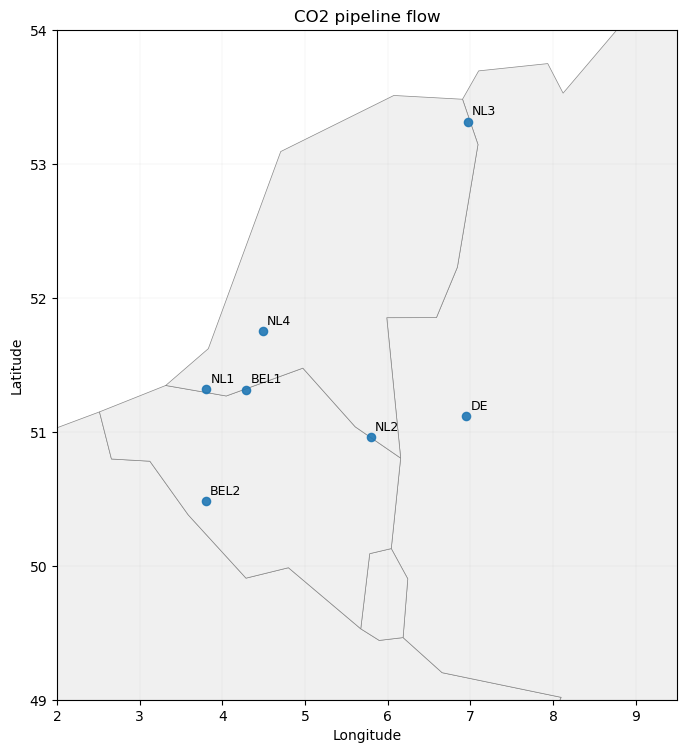

In [2]:
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import h5py
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString, Point

def _to_scalar(x):
    """Convert HDF5 dataset to Python scalar if possible, with special handling for bytes -> str."""
    if isinstance(x, (bytes, bytearray)):
        return x.decode("utf-8")
    if isinstance(x, np.generic):
        v = x.item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    x = np.asarray(x)
    if x.shape == ():
        v = x.item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    if x.size == 1:
        v = x.reshape(-1)[0].item()
        return v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v
    # array vero
    if x.dtype.kind in ("S", "O"):
        try:
            return np.vectorize(lambda b: b.decode("utf-8") if isinstance(b, (bytes, bytearray)) else b)(x)
        except Exception:
            pass
    return x

def read_network_edges(h5_path: str | Path,
                       year: str = "2022",
                       network: str = "hydrogenPipelineOnshore") -> pd.DataFrame:
    """
    design/networks/{year}/{network}/{edge_id}/...
    Reads the selected dataset along with fromNode and toNode if they exist.
    """
    h5_path = Path(h5_path)
    base = f"design/networks/{year}/{network}_existing"

    with h5py.File(h5_path, "r") as f:
        if base not in f:
            raise KeyError(f"Path '{base}' not found in the file.")
        g = f[base]
        edge_ids = list(g.keys())

        rows = []
        for eid in edge_ids:
            row = {"edge_id": eid}

            p_val = f"operation/networks/{year}/{network}_existing/{eid}/flow"
            p_from = f"{base}/{eid}/fromNode"
            p_to = f"{base}/{eid}/toNode"

            row['flow'] = (_to_scalar(f[p_val][()])).sum() if p_val in f else np.nan
            row["fromNode"] = _to_scalar(f[p_from][()]) if p_from in f else np.nan
            row["toNode"] = _to_scalar(f[p_to][()]) if p_to in f else np.nan
            rows.append(row)

    return pd.DataFrame(rows)

def attach_geometry(edges_df: pd.DataFrame, nodes_csv: str | Path) -> pd.DataFrame:
    """
    Adds lon/lat columns for from/to using plants_clusters_summary.csv
    (expected columns: cluster, latitude, longitude)
    """
    nodes = pd.read_csv(nodes_csv)
    nodes["cluster"] = nodes["cluster"].astype(str)

    coords = nodes.set_index("cluster")[["latitude", "longitude"]]

    out = edges_df.copy()
    out["fromNode"] = out["fromNode"].astype(str)
    out["toNode"]   = out["toNode"].astype(str)

    out["from_lat"] = out["fromNode"].map(coords["latitude"])
    out["from_lon"] = out["fromNode"].map(coords["longitude"])
    out["to_lat"]   = out["toNode"].map(coords["latitude"])
    out["to_lon"]   = out["toNode"].map(coords["longitude"])
    return out

def make_geopandas_map(edges_df: pd.DataFrame,
                       nodes_csv: str | Path,
                       weight_col: str = "capex",
                       bbox=(2.0, 49.0, 9.5, 54.0),
                       min_width=0.5,
                       max_width=6.0,
                       title=None):
    """
    Plots with GeoPandas + Matplotlib:
    - NaturalEarth basemap
    - nodes as points
    - edges as LineString with linewidth scaled on weight_col
    """
    nodes = pd.read_csv(nodes_csv)
    nodes["cluster"] = nodes["cluster"].astype(str)

    # GeoDataFrame nodes
    g_nodes = gpd.GeoDataFrame(
        nodes,
        geometry=gpd.points_from_xy(nodes["longitude"], nodes["latitude"]),
        crs="EPSG:4326"
    )

    # Filter valid edges and create LineString
    ed = edges_df.copy()
    ed[weight_col] = pd.to_numeric(ed[weight_col], errors="coerce")

    valid = ed[["from_lon","from_lat","to_lon","to_lat"]].notna().all(axis=1)
    ed = ed.loc[valid].copy()

    ed["geometry"] = ed.apply(
        lambda r: LineString([(r["from_lon"], r["from_lat"]), (r["to_lon"], r["to_lat"])]),
        axis=1
    )
    g_edges = gpd.GeoDataFrame(ed, geometry="geometry", crs="EPSG:4326")

    # Clip on bbox (lon_min, lat_min, lon_max, lat_max)
    lon_min, lat_min, lon_max, lat_max = bbox
    g_nodes_roi = g_nodes.cx[lon_min:lon_max, lat_min:lat_max]
    g_edges_roi = g_edges.cx[lon_min:lon_max, lat_min:lat_max]

    # Basemap
    world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")
    world_roi = world.cx[lon_min:lon_max, lat_min:lat_max]

    # Scale linewidth
    w = g_edges_roi[weight_col].to_numpy(dtype=float)
    w_pos = w[np.isfinite(w) & (w > 0)]
    w_max = float(w_pos.max()) if w_pos.size else 0.0

    def _lw(val):
        if not np.isfinite(val) or val <= 0 or w_max <= 0:
            return 0.0
        return min_width + (max_width - min_width) * (val / w_max)

    g_edges_roi["lw"] = g_edges_roi[weight_col].apply(_lw)

    # Plot
    fig, ax = plt.subplots(figsize=(8, 9))
    world_roi.plot(ax=ax, color="#f0f0f0", edgecolor="#888888", linewidth=0.5)

    # plot edges: draw only those with lw>0 (so zeros don't "pollute")
    g_edges_plot = g_edges_roi[g_edges_roi["lw"] > 0]
    if len(g_edges_plot):
        for lw_i in sorted(g_edges_plot["lw"].unique()):
            g_edges_plot[g_edges_plot["lw"] == lw_i].plot(ax=ax, linewidth=lw_i, alpha=0.8)

    # nodes
    g_nodes_roi.plot(ax=ax, markersize=35, alpha=0.9)

    # node labels (optional: comment out if cluttered)
    for _, r in g_nodes_roi.iterrows():
        ax.text(r["longitude"] + 0.05, r["latitude"] + 0.05, str(r["cluster"]), fontsize=9)

    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(title or f"Network {weight_col} (scaled linewidth)")
    ax.grid(True, linewidth=0.2, alpha=0.4)

    return fig, ax, g_nodes_roi, g_edges_roi


# main
h5_path = r"output\CO2_transport_20260216105501-1\optimization_results.h5"
nodes_csv = r"case_studies\CO2_transport\plants_clusters_summary.csv"
year = "2022"

edges = read_network_edges(h5_path, year=year, network="CO2_Pipeline")
edges = attach_geometry(edges, nodes_csv)

fig, ax, g_nodes_roi, g_edges_roi = make_geopandas_map(
    edges, nodes_csv, weight_col="flow",
    title="CO2 pipeline flow"
)
plt.show()


**Carriers input**

<>:96: SyntaxWarning: invalid escape sequence '\C'
<>:96: SyntaxWarning: invalid escape sequence '\C'
C:\Users\alessandro.magnino\AppData\Local\Temp\ipykernel_14040\4019821907.py:96: SyntaxWarning: invalid escape sequence '\C'
  h5_path = "output\CO2_transport_no_fossil_limited_MPW_20260216154456-1\optimization_results.h5"


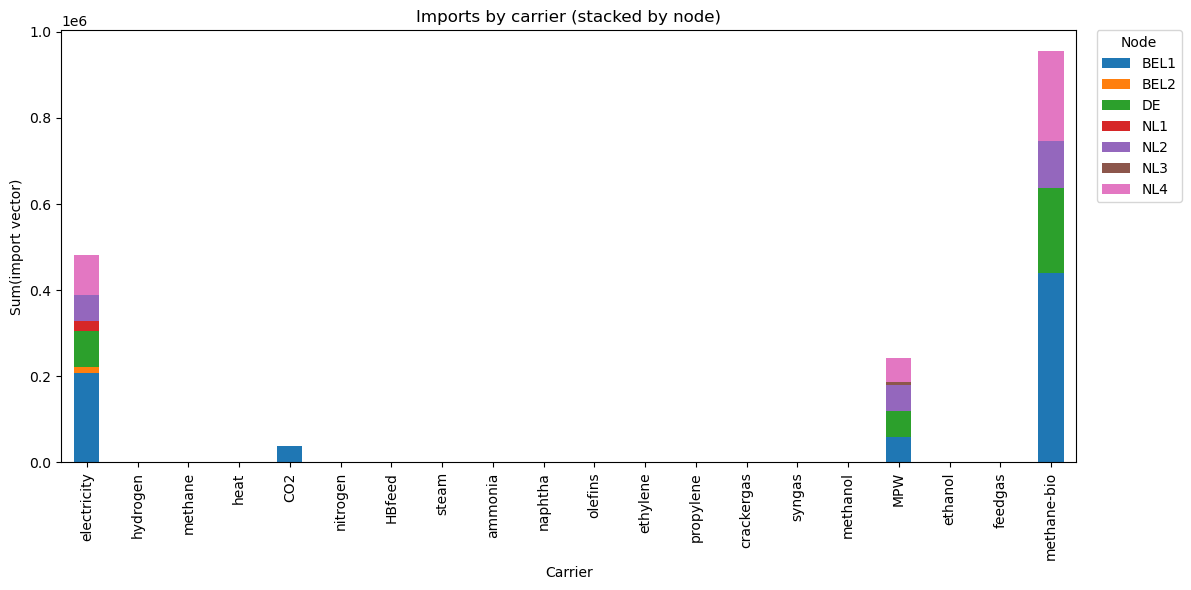

In [10]:
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt

def _safe_sum_dataset(ds) -> float:
    """Somma robusta del dataset (vector/array), tornando float."""
    a = np.asarray(ds[()])
    if a.size == 0:
        return 0.0
    return float(np.nansum(a.astype(float)))

def _read_nodes(nodes_csv: str | Path) -> list[str]:
    nodes = pd.read_csv(nodes_csv)
    if "cluster" not in nodes.columns:
        raise KeyError(f"No 'cluster' column found in {nodes_csv}. Found columns: {nodes.columns.tolist()}")
    return nodes["cluster"].astype(str).tolist()

def _read_carriers(carriers_xlsx: str | Path, sheet_name: str = "carriers") -> list[str]:
    df = pd.read_excel(carriers_xlsx, sheet_name=sheet_name)

    # Try to find a column that looks like "carrier" or "name" (case-insensitive), otherwise take the first column
    candidates = [c for c in ["carrier", "carriers", "name", "Carrier", "Name"] if c in df.columns]
    col = candidates[0] if candidates else df.columns[0]  # fallback: prima colonna

    carriers = (
        df[col]
        .dropna()
        .astype(str)
        .str.strip()
        .tolist()
    )
    return carriers

def read_imports_by_node_and_carrier(
    h5_path: str | Path,
    year: str,
    nodes: list[str],
    carriers: list[str],
    dataset_name: str = "import",
    base: str = "operation/energy_balance",
    missing_as_zero: bool = True,
) -> pd.DataFrame:
    """
    Read: /operation/energy_balance/{year}/{node}/{carrier}/import
    and sum vectors.
    """
    h5_path = Path(h5_path)

    rows = []
    with h5py.File(h5_path, "r") as f:
        for node in nodes:
            for car in carriers:
                ds_path = f"{base}/{year}/{node}/{car}/{dataset_name}"
                if ds_path in f:
                    total = _safe_sum_dataset(f[ds_path])
                else:
                    if missing_as_zero:
                        total = 0.0
                    else:
                        continue
                rows.append({"node": node, "carrier": car, "import_sum": total})

    return pd.DataFrame(rows)

def plot_stacked_imports(df: pd.DataFrame, node_order: list[str] | None = None, carrier_order: list[str] | None = None):
    """
    Colonne = carrier, stack = node.
    """
    d = df.copy()
    d["import_sum"] = pd.to_numeric(d["import_sum"], errors="coerce").fillna(0.0)

    pivot = d.pivot_table(index="carrier", columns="node", values="import_sum", aggfunc="sum", fill_value=0.0)

    if node_order is not None:
        pivot = pivot.reindex(columns=node_order)
    if carrier_order is not None:
        pivot = pivot.reindex(index=carrier_order)

    ax = pivot.plot(kind="bar", stacked=True, figsize=(12, 6))
    ax.set_xlabel("Carrier")
    ax.set_ylabel("Sum(import vector)")  # volutamente neutro (unità diverse)
    ax.set_title("Imports by carrier (stacked by node)")
    ax.legend(title="Node", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
    plt.tight_layout()
    plt.show()

# Main
case_study = "CO2_transport_no_fossil_limited_MPW"
nodes_csv = Path("case_studies") / case_study / "plants_clusters_summary.csv"
carriers_xlsx = Path("case_studies") / case_study / "carriers_list.xlsx"

# h5 dei risultati
h5_path = "output\CO2_transport_no_fossil_limited_MPW_20260216154456-1\optimization_results.h5"
year = "2022"

nodes = _read_nodes(nodes_csv)
carriers = _read_carriers(carriers_xlsx, sheet_name="carriers")

imports_df = read_imports_by_node_and_carrier(h5_path, year, nodes, carriers)

# (opzionale) ordine nodi/carrier
node_order = ["BEL1", "BEL2", "DE", "NL1", "NL2", "NL3", "NL4"]  # se vuoi
plot_stacked_imports(imports_df, node_order=node_order, carrier_order=carriers)
